<a href="https://colab.research.google.com/github/jin-raii/weather-web-app/blob/main/weather_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import csv
from datetime import datetime
import seaborn as sns

In [3]:
# with open('/content/gdrive/MyDrive/kathmandu_weather_data/data_kathmandu_weather.json') as f:
#   data = pd.read_json(f)
# # data = json.load('/content/gdrive/MyDrive/kathmandu_weather_data/data_kathmandu_weather.json')
# data.to_csv('/content/gdrive/MyDrive/kathmandu_weather_data/data_kathmandu.weather.csv', encoding='utf-8', index=False)

In [4]:
# df = pd.read_csv('/content/gdrive/MyDrive/kathmandu_weather_data/data_kathmandu.weather.csv')

In [5]:
# df.head()

In [6]:
# def json_to_csv(json_file, csv_file):
#   try:
#     with open(json_file) as f:
#       data = json.load(f)
#       print(data)
#   except Exception as e:
#     print(f'something went wrong: {e}')

#   try:
#     with open(csv_file, 'w', newline='') as f:
#       write_col = csv.DictWriter(f, fieldnames=data[0].keys())
#       write_col.writeheader()

#       for i in data:
#         write_col.writerow(i)
#     print(f'successfully write csv file to {csv_file}')
#   except Exception as e:
#     print(f'something went wrong {e}')


In [7]:
# json_to_csv('/content/gdrive/MyDrive/kathmandu_weather_data/data_kathmandu_weather.json', '/content/gdrive/MyDrive/kathmandu_weather_data/kathmandu.weather.csv')

In [8]:
# df = pd.read_csv('/content/gdrive/MyDrive/kathmandu_weather_data/kathmandu.weather.csv')
# df.head()

In [9]:
def flatten_weather_data(data_list):
    flattened_data = []
    with open(data_list, 'r') as d:
      data = json.load(d)

    for item in data:
        flat_dict = {
            'timestamp': datetime.fromtimestamp(item['timestamp']).strftime('%Y-%m-%d %H:%M:%S'),
            'longitude': item['data']['coord']['lon'],
            'latitude': item['data']['coord']['lat'],
            'weather_id': item['data']['weather'][0]['id'],
            'weather_main': item['data']['weather'][0]['main'],
            'weather_description': item['data']['weather'][0]['description'],
            'temperature': item['data']['main']['temp'],
            'feels_like': item['data']['main']['feels_like'],
            'temp_min': item['data']['main']['temp_min'],
            'temp_max': item['data']['main']['temp_max'],
            'pressure': item['data']['main']['pressure'],
            'humidity': item['data']['main']['humidity'],
            'sea_level': item['data']['main']['sea_level'],
            'ground_level': item['data']['main']['grnd_level'],
            'visibility': item['data']['visibility'],
            'wind_speed': item['data']['wind']['speed'],
            'wind_degree': item['data']['wind']['deg'],
            'clouds_percentage': item['data']['clouds']['all'],
            'country': item['data']['sys']['country'],
            'sunrise': datetime.fromtimestamp(item['data']['sys']['sunrise']).strftime('%Y-%m-%d %H:%M:%S'),
            'sunset': datetime.fromtimestamp(item['data']['sys']['sunset']).strftime('%Y-%m-%d %H:%M:%S'),
            'timezone': item['data']['timezone'],
            'city_id': item['data']['id'],
            'city_name': item['data']['name']
        }
        flattened_data.append(flat_dict)

    return flattened_data

In [10]:
df_ = pd.DataFrame(flatten_weather_data('/content/gdrive/MyDrive/kathmandu_weather_data/data_kathmandu_weather.json'))
df_.head()

,timestamp,longitude,latitude,weather_id,weather_main,weather_description,temperature,feels_like,temp_min,temp_max,...,visibility,wind_speed,wind_degree,clouds_percentage,country,sunrise,sunset,timezone,city_id,city_name
0,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
1,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
2,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
3,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
4,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali


In [11]:
df_.to_csv('/content/gdrive/MyDrive/kathmandu_weather_data/kathmandu.weather.csv', encoding='utf-8', index=False)

In [12]:
data = pd.read_csv('/content/gdrive/MyDrive/kathmandu_weather_data/kathmandu.weather.csv')
data.describe()

,longitude,latitude,weather_id,temperature,feels_like,temp_min,temp_max,pressure,humidity,sea_level,ground_level,visibility,wind_speed,wind_degree,clouds_percentage,timezone,city_id
count,63795.000000,6.379500e+04,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.0,63795.0
mean,85.324000,2.771720e+01,757.104836,286.275594,285.549668,286.275594,286.275594,1013.646587,69.152379,1013.646587,849.942848,5266.357865,2.080942,117.674269,33.370092,20700.0,1282682.0
std,0.000002,1.904980e-11,46.382713,3.723176,3.516453,3.723176,3.723176,2.592418,19.063112,2.592418,1.736514,1552.782738,1.629196,105.049298,20.606924,0.0,0.0
min,85.323900,2.771720e+01,701.000000,280.300000,278.970000,280.300000,280.300000,1007.000000,24.000000,1007.000000,846.000000,1500.000000,0.000000,0.000000,20.000000,20700.0,1282682.0
25%,85.324000,2.771720e+01,701.000000,283.300000,282.490000,283.300000,283.300000,1012.000000,55.000000,1012.000000,849.000000,4500.000000,1.030000,0.000000,20.000000,20700.0,1282682.0
50%,85.324000,2.771720e+01,801.000000,285.300000,284.840000,285.300000,285.300000,1014.000000,72.000000,1014.000000,850.000000,6000.000000,1.540000,120.000000,20.000000,20700.0,1282682.0
75%,85.324000,2.771720e+01,801.000000,289.300000,288.410000,289.300000,289.300000,1015.000000,82.000000,1015.000000,851.000000,6000.000000,3.090000,220.000000,40.000000,20700.0,1282682.0
max,85.324000,2.771720e+01,803.000000,293.300000,292.260000,293.300000,293.300000,1019.000000,100.000000,1019.000000,854.000000,8000.000000,7.200000,350.000000,75.000000,20700.0,1282682.0


In [13]:
data.isnull().sum().sum()

0

In [14]:
data.duplicated().sum()

61901

In [15]:
len(data)

63795

In [16]:
data.head()

,timestamp,longitude,latitude,weather_id,weather_main,weather_description,temperature,feels_like,temp_min,temp_max,...,visibility,wind_speed,wind_degree,clouds_percentage,country,sunrise,sunset,timezone,city_id,city_name
0,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
1,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
2,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
3,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali
4,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,2000,1.54,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali


In [17]:
data.duplicated(subset=['temperature', 'humidity', 'wind_speed', 'pressure'], keep=False).sum()

63795

In [18]:
### group by minute
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63795 entries, 0 to 63794
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            63795 non-null  object 
 1   longitude            63795 non-null  float64
 2   latitude             63795 non-null  float64
 3   weather_id           63795 non-null  int64  
 4   weather_main         63795 non-null  object 
 5   weather_description  63795 non-null  object 
 6   temperature          63795 non-null  float64
 7   feels_like           63795 non-null  float64
 8   temp_min             63795 non-null  float64
 9   temp_max             63795 non-null  float64
 10  pressure             63795 non-null  int64  
 11  humidity             63795 non-null  int64  
 12  sea_level            63795 non-null  int64  
 13  ground_level         63795 non-null  int64  
 14  visibility           63795 non-null  int64  
 15  wind_speed           63795 non-null 

### Convert datetime to datetime object

In [19]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['sunrise'] = pd.to_datetime(data['sunrise'])
data['sunset'] = pd.to_datetime(data['sunset'])

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63795 entries, 0 to 63794
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            63795 non-null  datetime64[ns]
 1   longitude            63795 non-null  float64       
 2   latitude             63795 non-null  float64       
 3   weather_id           63795 non-null  int64         
 4   weather_main         63795 non-null  object        
 5   weather_description  63795 non-null  object        
 6   temperature          63795 non-null  float64       
 7   feels_like           63795 non-null  float64       
 8   temp_min             63795 non-null  float64       
 9   temp_max             63795 non-null  float64       
 10  pressure             63795 non-null  int64         
 11  humidity             63795 non-null  int64         
 12  sea_level            63795 non-null  int64         
 13  ground_level         63795 non-

In [21]:
data.tail()

,timestamp,longitude,latitude,weather_id,weather_main,weather_description,temperature,feels_like,temp_min,temp_max,...,visibility,wind_speed,wind_degree,clouds_percentage,country,sunrise,sunset,timezone,city_id,city_name
63790,2025-02-18 01:33:16,85.324,27.7172,701,Mist,mist,282.3,281.79,282.3,282.3,...,2000,1.54,180,20,NP,2025-02-18 00:53:49,2025-02-18 12:11:46,20700,1282682,Thapathali
63791,2025-02-18 01:33:16,85.324,27.7172,701,Mist,mist,282.3,281.79,282.3,282.3,...,2000,1.54,180,20,NP,2025-02-18 00:53:49,2025-02-18 12:11:46,20700,1282682,Thapathali
63792,2025-02-18 01:33:16,85.324,27.7172,701,Mist,mist,282.3,281.79,282.3,282.3,...,2000,1.54,180,20,NP,2025-02-18 00:53:49,2025-02-18 12:11:46,20700,1282682,Thapathali
63793,2025-02-18 01:33:16,85.324,27.7172,701,Mist,mist,282.3,281.79,282.3,282.3,...,2000,1.54,180,20,NP,2025-02-18 00:53:49,2025-02-18 12:11:46,20700,1282682,Thapathali
63794,2025-02-18 01:33:16,85.324,27.7172,701,Mist,mist,282.3,281.79,282.3,282.3,...,2000,1.54,180,20,NP,2025-02-18 00:53:49,2025-02-18 12:11:46,20700,1282682,Thapathali


In [22]:
data['weather_description'].unique()

array(['mist', 'haze', 'few clouds', 'scattered clouds', 'broken clouds'],
      dtype=object)

In [23]:
data['minute'] = data['timestamp'].dt.floor('min')

In [24]:
second = data['timestamp'].dt.second

In [25]:
data.columns

Index(['timestamp', 'longitude', 'latitude', 'weather_id', 'weather_main',
       'weather_description', 'temperature', 'feels_like', 'temp_min',
       'temp_max', 'pressure', 'humidity', 'sea_level', 'ground_level',
       'visibility', 'wind_speed', 'wind_degree', 'clouds_percentage',
       'country', 'sunrise', 'sunset', 'timezone', 'city_id', 'city_name',
       'minute'],
      dtype='object')

In [26]:
unique_res = data.groupby('minute').agg({ 'temperature': 'nunique',
        'humidity': 'nunique',
        'wind_speed': 'nunique',
        'pressure': 'nunique'})
unique_res

,temperature,humidity,wind_speed,pressure
minute,,,,
2025-02-12 01:44:00,1,1,1,1
2025-02-12 01:56:00,1,1,1,1
2025-02-12 01:59:00,1,1,1,1
2025-02-12 02:03:00,1,1,1,1
2025-02-12 02:11:00,1,1,1,1
...,...,...,...,...
2025-02-18 01:19:00,1,1,1,1
2025-02-18 01:26:00,1,1,1,1
2025-02-18 01:28:00,1,1,1,1


Text(0, 0.5, 'Temperature')

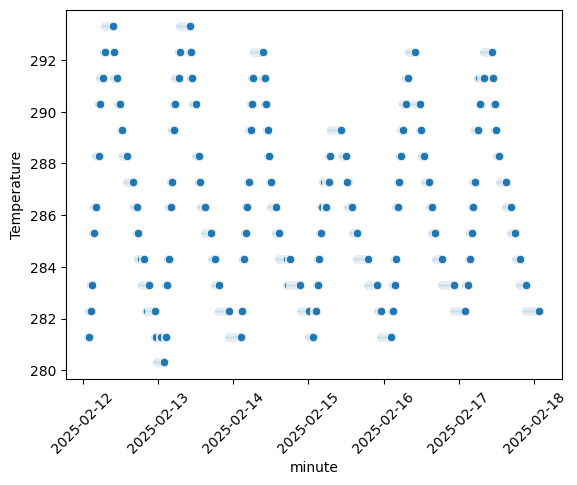

In [27]:
sns.scatterplot(data=data, x='minute', y='temperature')
plt.xticks(rotation=45)
plt.ylabel('Temperature')

In [28]:
# data['second']

In [29]:
data.loc[data['temperature'] < 5 ]

,timestamp,longitude,latitude,weather_id,weather_main,weather_description,temperature,feels_like,temp_min,temp_max,...,wind_speed,wind_degree,clouds_percentage,country,sunrise,sunset,timezone,city_id,city_name,minute


(array([20131., 20132., 20133., 20134., 20135., 20136., 20137.]),
 [Text(20131.0, 0, '2025-02-12'),
  Text(20132.0, 0, '2025-02-13'),
  Text(20133.0, 0, '2025-02-14'),
  Text(20134.0, 0, '2025-02-15'),
  Text(20135.0, 0, '2025-02-16'),
  Text(20136.0, 0, '2025-02-17'),
  Text(20137.0, 0, '2025-02-18')])

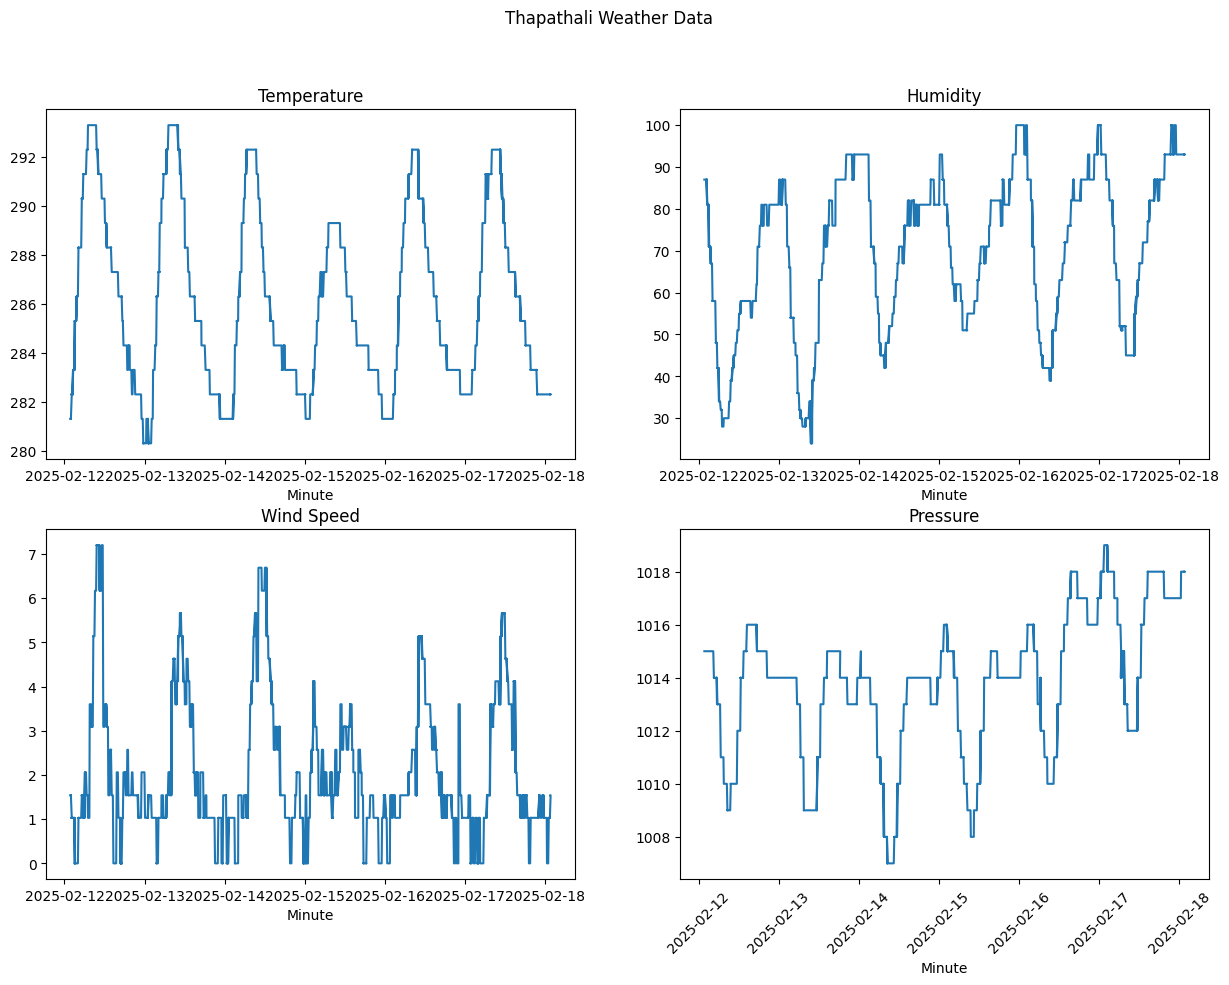

In [30]:

figure, axis = plt.subplots(2,2, figsize=(15,10))

figure.suptitle('Thapathali Weather Data')
axis[0, 0].plot(data['minute'], data['temperature'])
axis[0,0].set_title('Temperature')
axis[0,0].set_xlabel('Minute')
plt.xticks(rotation=45)

axis[0, 1].plot(data['minute'],data['humidity'])
axis[0,1].set_title('Humidity')
axis[0,1].set_xlabel('Minute')

axis[1,0].plot(data['minute'], data['wind_speed'])
axis[1, 0].set_title('Wind Speed')
axis[1,0].set_xlabel('Minute')
plt.xticks(rotation=45)

axis[1,1].plot(data['minute'], data['pressure'])
axis[1,1].set_title('Pressure')
axis[1,1].set_xlabel('Minute')
plt.xticks(rotation=45)

In [31]:
print(f"temp len : {len(data['temperature'])}\nHumidity len: {len(data['humidity'])}\nWind speed: {len(data['wind_speed'])}\nPressure len {len(data['pressure'])} ")


temp len : 63795
Humidity len: 63795
Wind speed: 63795
Pressure len 63795 


In [32]:
data['minute'].head()

,minute
0,2025-02-12 01:44:00
1,2025-02-12 01:44:00
2,2025-02-12 01:44:00
3,2025-02-12 01:59:00
4,2025-02-12 01:59:00


In [33]:
second.head()

,timestamp
0,14
1,14
2,14
3,58
4,58


<Axes: xlabel='wind_speed', ylabel='temperature'>

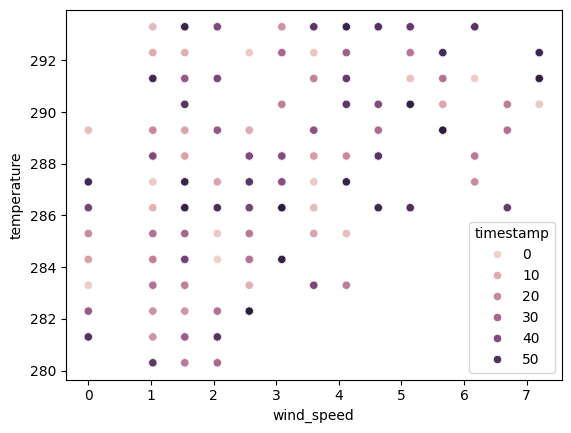

In [34]:
sns.scatterplot(data=data, x='wind_speed', y='temperature', hue=second)

In [35]:
data['second'] = data['timestamp'].dt.second

In [36]:
data.loc[data['second'].unique()].head()

,timestamp,longitude,latitude,weather_id,weather_main,weather_description,temperature,feels_like,temp_min,temp_max,...,wind_degree,clouds_percentage,country,sunrise,sunset,timezone,city_id,city_name,minute,second
14,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58
58,2025-02-12 01:56:32,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:56:00,32
32,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58
10,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58
39,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58


([0, 1, 2, 3, 4],
 [Text(0, 0, 'mist'),
  Text(1, 0, 'haze'),
  Text(2, 0, 'few clouds'),
  Text(3, 0, 'scattered clouds'),
  Text(4, 0, 'broken clouds')])

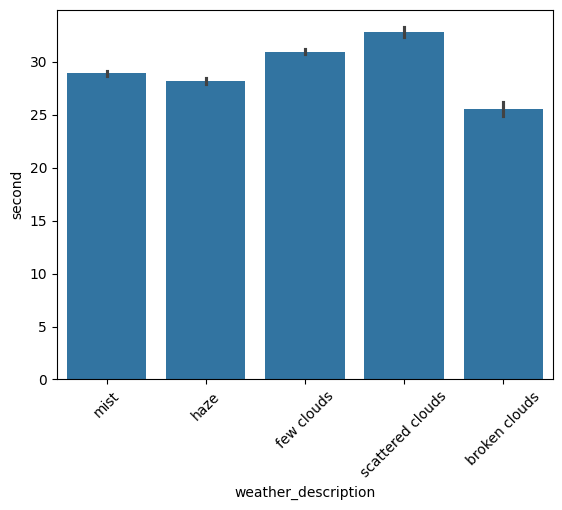

In [37]:
sns.barplot(data=data, y='second', x='weather_description')
plt.xticks(rotation=45)

In [38]:
data['weather_main'].unique()

array(['Mist', 'Haze', 'Clouds'], dtype=object)

In [39]:
data['temperature'].unique()

array([281.3, 282.3, 283.3, 285.3, 286.3, 288.3, 290.3, 291.3, 292.3,
       293.3, 289.3, 287.3, 284.3, 280.3])

In [40]:
data['temperature'].nunique()

14

In [41]:
data.nunique()

,0
timestamp,1893
longitude,2
latitude,1
weather_id,5
weather_main,3
weather_description,5
temperature,14
feels_like,70
temp_min,14
temp_max,14


<Axes: title={'center': 'Temperature Plot in second'}, xlabel='second', ylabel='temperature'>

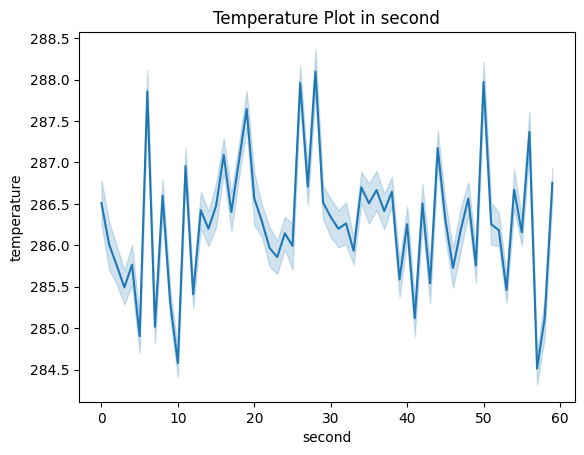

In [42]:
plt.title('Temperature Plot in second')
sns.lineplot(data=data, x='second', y='temperature')

In [43]:
data.head()

,timestamp,longitude,latitude,weather_id,weather_main,weather_description,temperature,feels_like,temp_min,temp_max,...,wind_degree,clouds_percentage,country,sunrise,sunset,timezone,city_id,city_name,minute,second
0,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:44:00,14
1,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:44:00,14
2,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:44:00,14
3,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58
4,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58


In [44]:
final_data = data.drop(columns=['timestamp', 'longitude', 'latitude', 'weather_id', 'country', 'city_id', 'city_name', 'sunrise', 'sunset', 'timezone', 'weather_main'], axis=1)
final_data.head()

,weather_description,temperature,feels_like,temp_min,temp_max,pressure,humidity,sea_level,ground_level,visibility,wind_speed,wind_degree,clouds_percentage,minute,second
0,mist,281.3,280.64,281.3,281.3,1015,87,1015,850,2000,1.54,100,20,2025-02-12 01:44:00,14
1,mist,281.3,280.64,281.3,281.3,1015,87,1015,850,2000,1.54,100,20,2025-02-12 01:44:00,14
2,mist,281.3,280.64,281.3,281.3,1015,87,1015,850,2000,1.54,100,20,2025-02-12 01:44:00,14
3,mist,281.3,280.64,281.3,281.3,1015,87,1015,850,2000,1.54,100,20,2025-02-12 01:59:00,58
4,mist,281.3,280.64,281.3,281.3,1015,87,1015,850,2000,1.54,100,20,2025-02-12 01:59:00,58


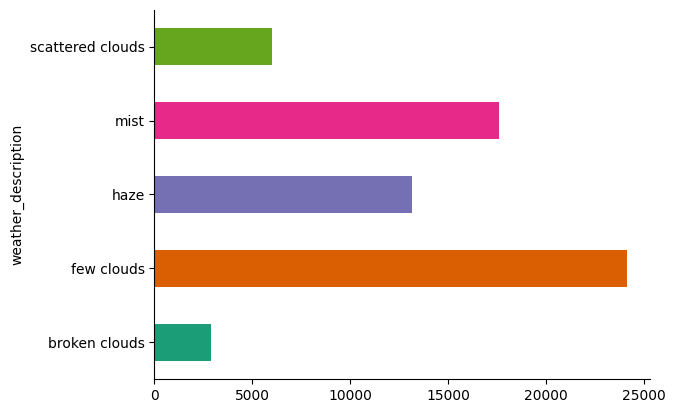

In [45]:
# @title weather_description

from matplotlib import pyplot as plt
import seaborn as sns
final_data.groupby('weather_description').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

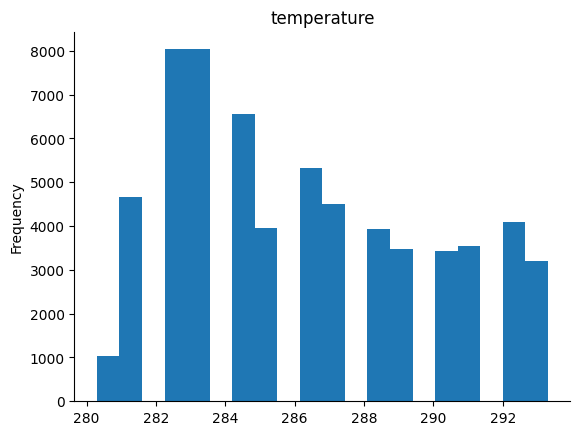

In [46]:
# @title temperature

from matplotlib import pyplot as plt
final_data['temperature'].plot(kind='hist', bins=20, title='temperature')
plt.gca().spines[['top', 'right',]].set_visible(False)

<Axes: xlabel='weather_description', ylabel='temperature'>

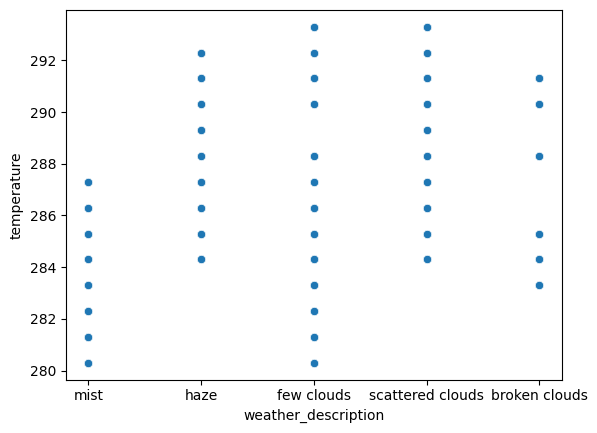

In [47]:
sns.scatterplot(data=data, y='temperature', x='weather_description')

In [48]:
mist = data.loc[data['weather_description']=='mist']
haze = data.loc[data['weather_description']=='haze']

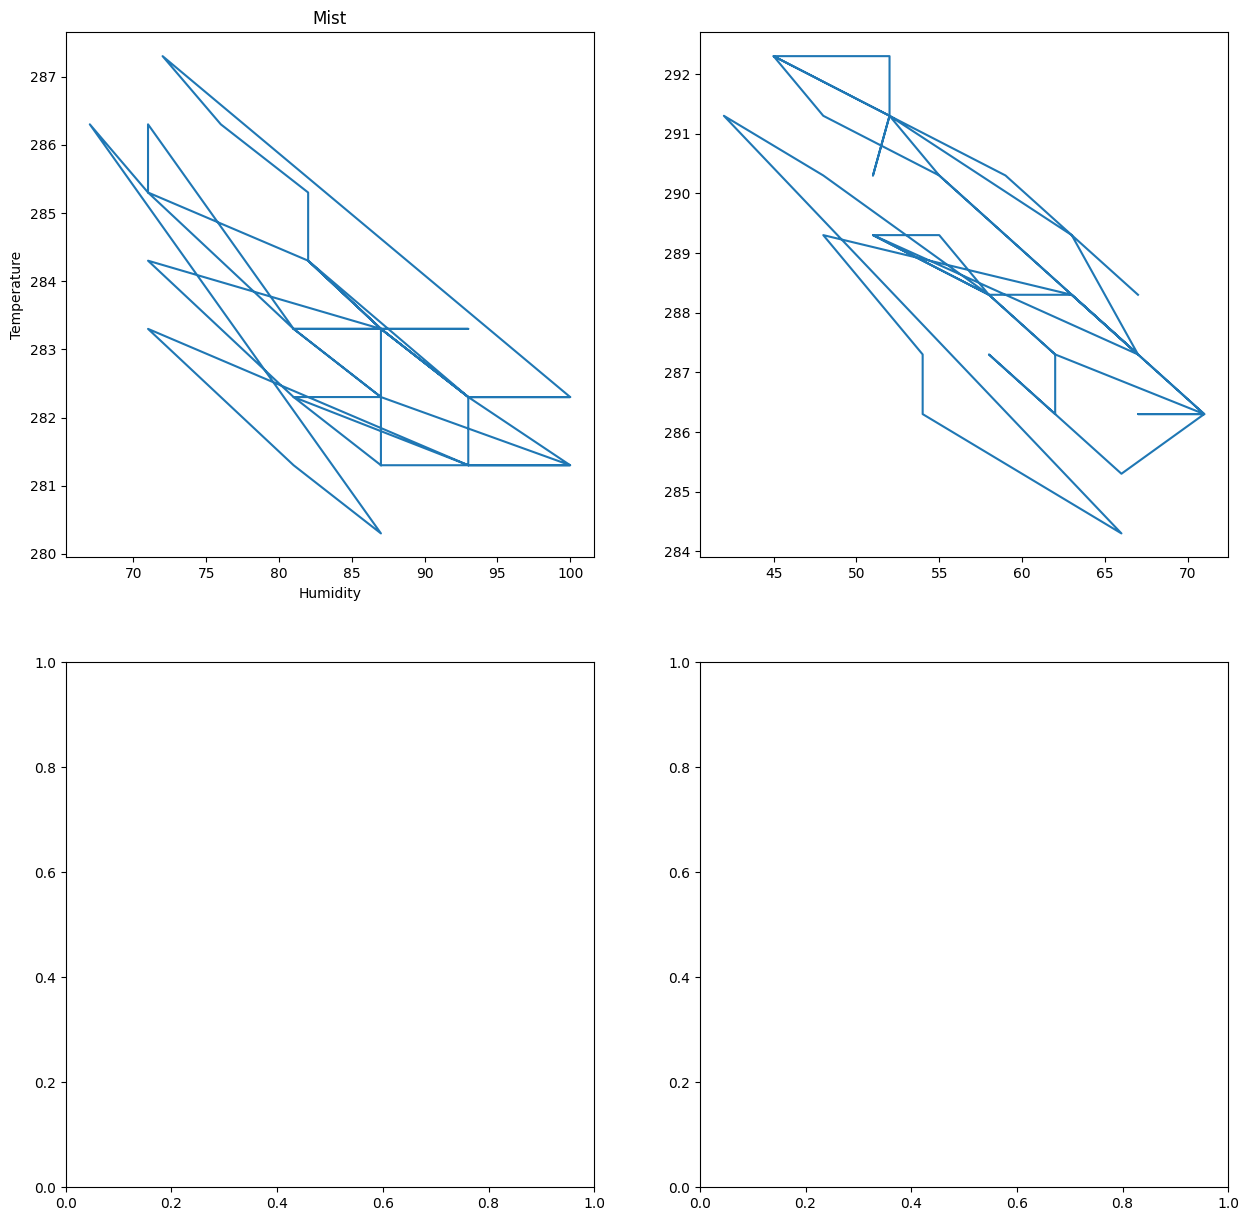

<Axes: xlabel='humidity', ylabel='temperature'>

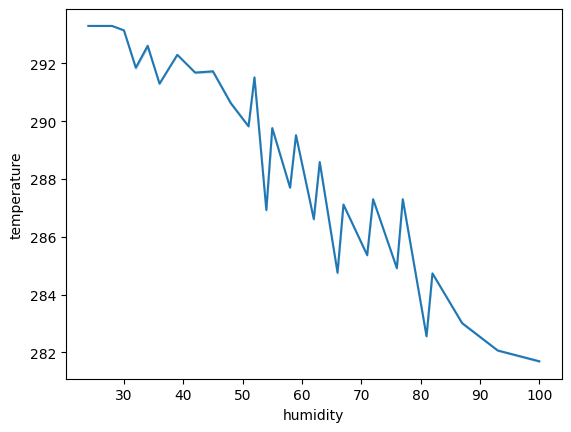

In [49]:
fig, ax = plt.subplots(2, 2, figsize=(15, 15))
ax[0,0].plot(mist['humidity'], mist['temperature'])
ax[0,0].set_title('Mist')
ax[0,0].set_xlabel('Humidity')
ax[0,0].set_ylabel('Temperature')
# plt.xticks(rotation=45)
ax[0,1].plot(haze['humidity'], haze['temperature'])
plt.show()
sns.lineplot(data=data, x='humidity', y='temperature')

In [50]:
data.head()

,timestamp,longitude,latitude,weather_id,weather_main,weather_description,temperature,feels_like,temp_min,temp_max,...,wind_degree,clouds_percentage,country,sunrise,sunset,timezone,city_id,city_name,minute,second
0,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:44:00,14
1,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:44:00,14
2,2025-02-12 01:44:14,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:44:00,14
3,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58
4,2025-02-12 01:59:58,85.324,27.7172,701,Mist,mist,281.3,280.64,281.3,281.3,...,100,20,NP,2025-02-12 00:58:36,2025-02-12 12:07:28,20700,1282682,Thapathali,2025-02-12 01:59:00,58


In [51]:
data.describe()

,timestamp,longitude,latitude,weather_id,temperature,feels_like,temp_min,temp_max,pressure,humidity,...,visibility,wind_speed,wind_degree,clouds_percentage,sunrise,sunset,timezone,city_id,minute,second
count,63795,63795.000000,6.379500e+04,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,63795.000000,...,63795.000000,63795.000000,63795.000000,63795.000000,63795,63795,63795.0,63795.0,63795,63795.000000
mean,2025-02-14 17:36:52.660490496,85.324000,2.771720e+01,757.104836,286.275594,285.549668,286.275594,286.275594,1013.646587,69.152379,...,5266.357865,2.080942,117.674269,33.370092,2025-02-14 12:15:41.915432448,2025-02-14 23:28:16.750482176,20700.0,1282682.0,2025-02-14 17:36:22.904302592,29.756188
min,2025-02-12 01:44:14,85.323900,2.771720e+01,701.000000,280.300000,278.970000,280.300000,280.300000,1007.000000,24.000000,...,1500.000000,0.000000,0.000000,20.000000,2025-02-12 00:58:36,2025-02-12 12:07:28,20700.0,1282682.0,2025-02-12 01:44:00,0.000000
25%,2025-02-13 04:44:06,85.324000,2.771720e+01,701.000000,283.300000,282.490000,283.300000,283.300000,1012.000000,55.000000,...,4500.000000,1.030000,0.000000,20.000000,2025-02-13 00:57:51,2025-02-13 12:08:12,20700.0,1282682.0,2025-02-13 04:44:00,15.000000
50%,2025-02-14 13:30:29,85.324000,2.771720e+01,801.000000,285.300000,284.840000,285.300000,285.300000,1014.000000,72.000000,...,6000.000000,1.540000,120.000000,20.000000,2025-02-14 00:57:04,2025-02-14 12:08:56,20700.0,1282682.0,2025-02-14 13:30:00,30.000000
75%,2025-02-16 04:26:04,85.324000,2.771720e+01,801.000000,289.300000,288.410000,289.300000,289.300000,1015.000000,82.000000,...,6000.000000,3.090000,220.000000,40.000000,2025-02-16 00:55:29,2025-02-16 12:10:22,20700.0,1282682.0,2025-02-16 04:26:00,44.000000
max,2025-02-18 01:39:53,85.324000,2.771720e+01,803.000000,293.300000,292.260000,293.300000,293.300000,1019.000000,100.000000,...,8000.000000,7.200000,350.000000,75.000000,2025-02-18 00:53:49,2025-02-18 12:11:46,20700.0,1282682.0,2025-02-18 01:39:00,59.000000
std,NaN,0.000002,1.904980e-11,46.382713,3.723176,3.516453,3.723176,3.723176,2.592418,19.063112,...,1552.782738,1.629196,105.049298,20.606924,NaN,NaN,0.0,0.0,NaN,16.987642


In [61]:
count_day = data['timestamp'].dt.day
count_day

,timestamp
0,12
1,12
2,12
3,12
4,12
...,...
63790,18
63791,18
63792,18
63793,18


<Axes: xlabel='timestamp', ylabel='weather_description'>

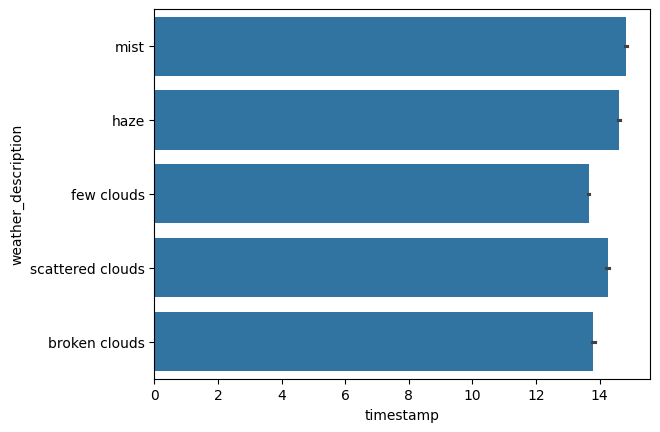

In [64]:
sns.barplot(data=data, x=count_day, y='weather_description')

<Axes: xlabel='timestamp', ylabel='humidity'>

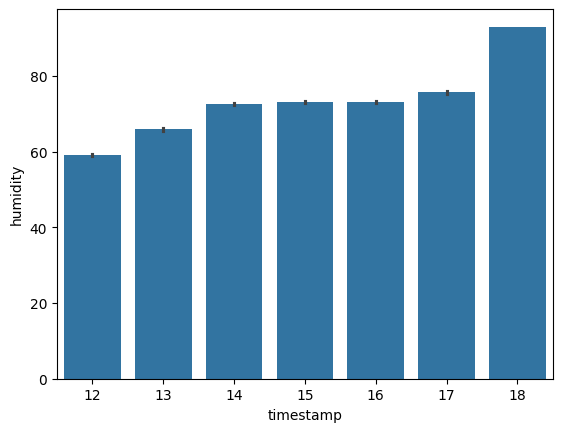

In [77]:
sns.barplot(data=data, x=count_day, y='humidity')

<Axes: xlabel='timestamp', ylabel='pressure'>

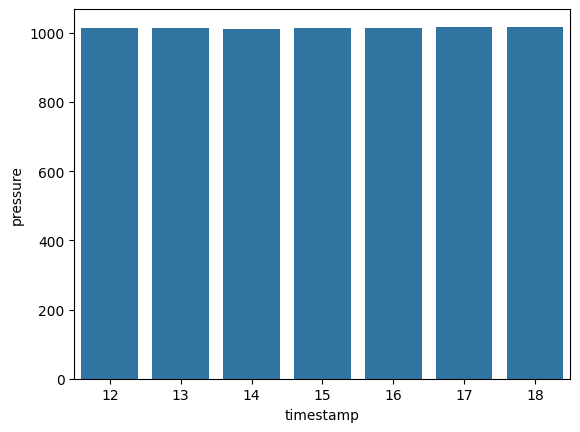

In [78]:
sns.barplot(data=data, x=count_day, y='pressure')

<Axes: xlabel='timestamp', ylabel='wind_speed'>

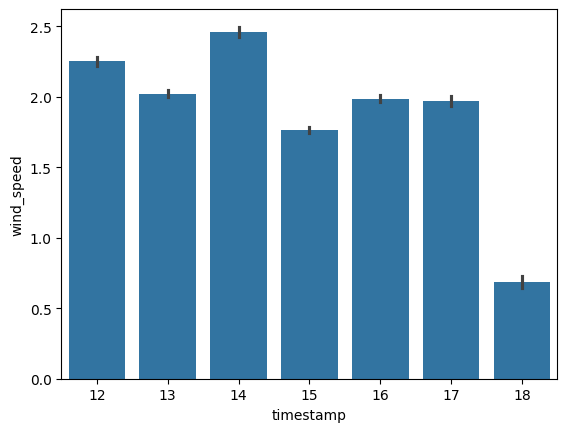

In [79]:
sns.barplot(data=data, x=count_day, y='wind_speed')

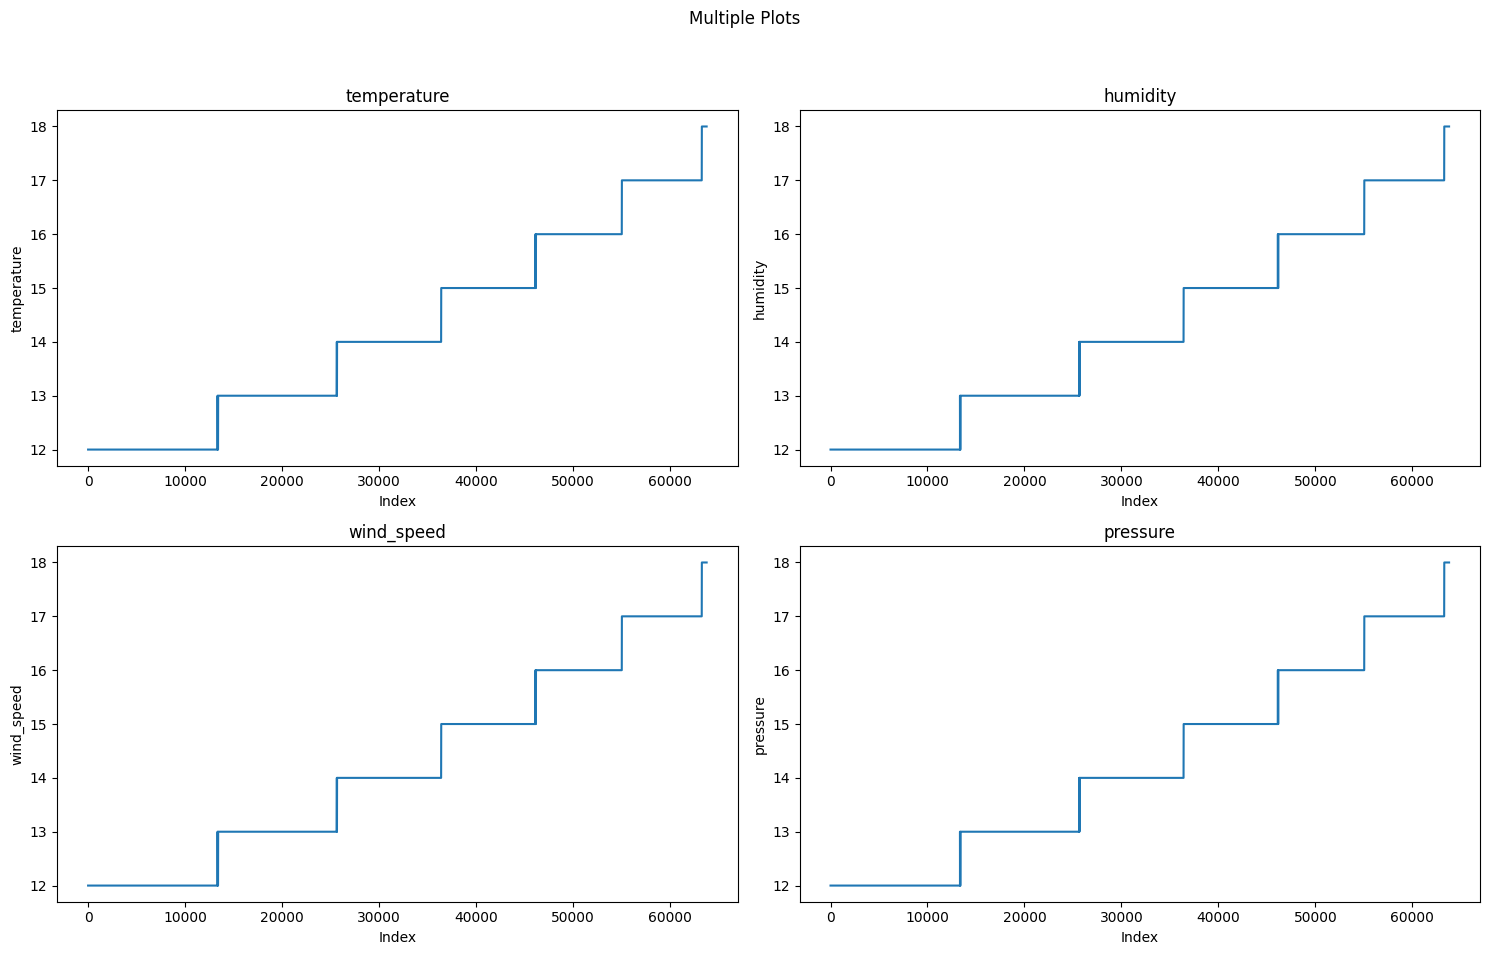

In [71]:
# prompt: multiple plot using for loop

import matplotlib.pyplot as plt

# Assuming 'final_data' DataFrame is already defined from the previous code

columns_to_plot = ['temperature', 'humidity', 'wind_speed', 'pressure']
num_plots = len(columns_to_plot)
rows = 2
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
fig.suptitle('Multiple Plots')

for i, col in enumerate(columns_to_plot):
    row = i // cols
    col_idx = i % cols
    axes[row, col_idx].plot(count_day)  # Adjust x-axis as needed
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('Index')  # Replace 'Index' with appropriate x-axis label
    axes[row, col_idx].set_ylabel(col) # Replace with relevant y-axis label

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping
plt.show()
